5-Fold CV Evaluation Progress: 100%|█████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.63it/s]


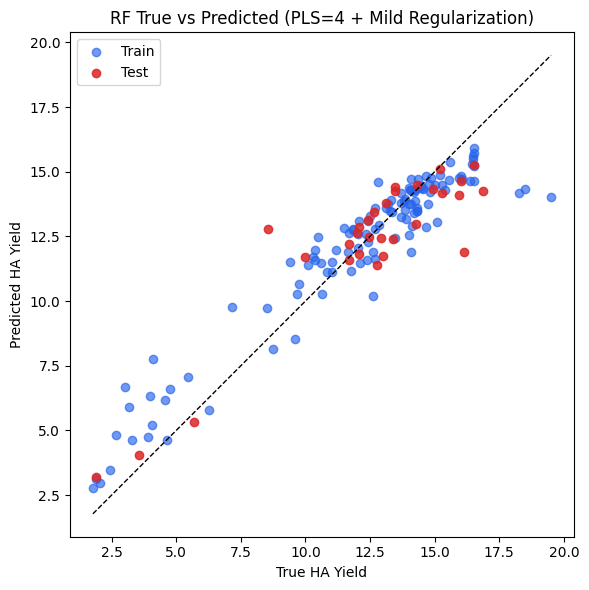

RF Mild Regularization Fixed Parameters:
{'n_estimators': 1000, 'max_depth': 9, 'max_features': 0.5, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_samples': 0.8, 'bootstrap': True, 'ccp_alpha': 0.003}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2069%

===== Cross-Validation (5 fold Max R2 Fold, Use This R2 to Judge Overfitting) =====
MSE : 3.5784
RMSE: 1.8917
MAE : 1.3423
MRE : 20.23%
R2  : 0.7394

===== Training Set Metrics =====
MSE: 1.8560
RMSE: 1.3623
MAE: 0.9938
MRE: 12.96%
R2: 0.8855

===== Test Set Metrics =====
MSE: 2.2318
RMSE: 1.4939
MAE: 1.0975
MRE: 10.84%
R2: 0.8169

Start band harm analysis via random masking fine trial
Baseline Test R² (No Mask): 0.8169
Start 500 random masking trials (mask ratio 5%)...


Random Masking Trials (5%): 100%|████████████████████████████████████████████████████| 500/500 [05:33<00:00,  1.50it/s]



Bands with positive harm score: 0
Max harm score: -0.074261
Min harm score: -0.136063


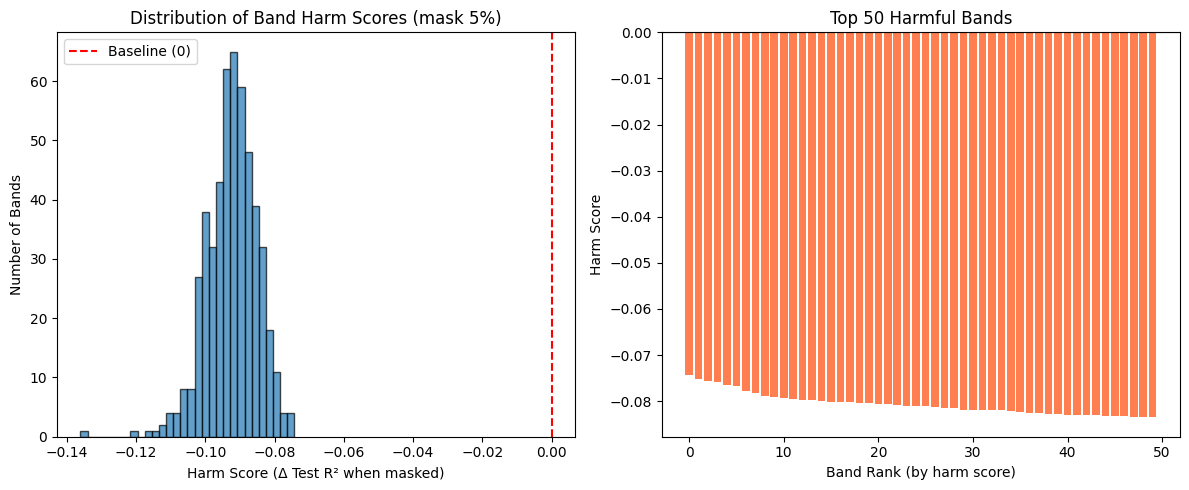


===== Ablation Test: Gradually Remove Harmful Bands Fine Range =====


Ablation Remove: 100%|█████████████████████████████████████████████████████████████████| 41/41 [00:26<00:00,  1.53it/s]


Optimal Result: Remove 80 harmful bands, Test R² = 0.8365 (Baseline 0.8169)


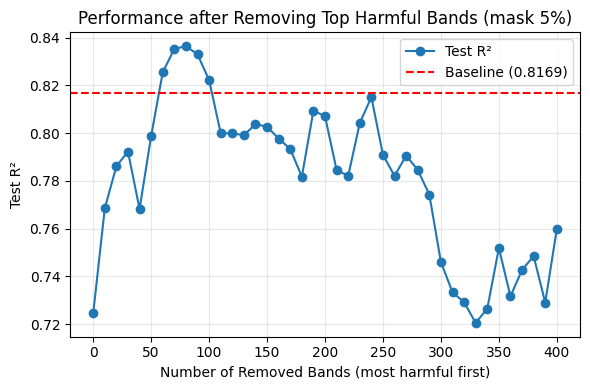


✅ After removing 80 most harmful bands, Test R² improved from 0.8169 to 0.8365.
Suggest permanent removal of these bands for final model training.
Removed band indices (0-based): [184 409 443 467 321 338 233 279 414 483 284 473 209 332 296 399 238 303
 253 330 324 347 204 380 487 260 477 431 217 360 393 295 340 484 342 287
 268 508 372 377 285 458 325 404 319 364 313 365 370 359 463 322 452 222
 390 457 415 429 335 250 381 379 405 239 103 293 304 378 354 153 374 428
 421 278 273 195 416 288 439 478]
Removed feature list saved in Excel.

Harm analysis outputs saved to: E:\YRH-HSI\python data\MUST\rf_ablation_random_mask_fine
Optimal band true vs predicted values saved to: E:\YRH-HSI\python data\MUST\rf_ablation_random_mask_fine\optimal_band_predictions.xlsx

Start screening minimal key band subset (constraints: Test R² drop ≤5% + overfitting control)
Baseline full-spectrum Test R²: 0.8169
Minimum allowed Test R² threshold (-5% drop): 0.7761
Overfitting constraint: Train R² - Test R² ≤ 

Coarse search for key band count: 100%|████████████████████████████████████████████████| 53/53 [00:40<00:00,  1.30it/s]


✅ Minimal valid key band count satisfying all constraints: 231
Performance with 231 retained key bands:
  Train R² = 0.8740, Test R² = 0.7783
  Actual PLS components used: 4
  Relative R² drop ratio: 4.73% (≤5% constraint satisfied)
  Train-test R² gap: 0.0957 (≤0.15 overfitting constraint satisfied)
Optimal minimal key band list saved to: E:\YRH-HSI\python data\MUST\rf_ablation_random_mask_fine\optimal_min_key_bands.xlsx


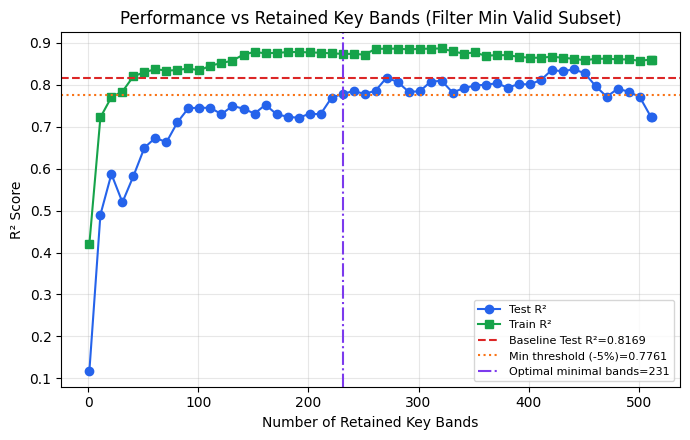

Full key band search log saved to: E:\YRH-HSI\python data\MUST\rf_ablation_random_mask_fine\key_band_search_all_records.xlsx
Minimal key band true-prediction data saved to: E:\YRH-HSI\python data\MUST\rf_ablation_random_mask_fine\min_key_band_predictions.xlsx

Conclusion: Only 231 core bands required to meet criteria, input dimension largely reduced!


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm
import time

warnings.filterwarnings("ignore")

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"
output_path = spectra_path.with_name("RF.xlsx")
output_dir = spectra_path.parent / "rf_pls4_mild_reg_visual"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)
id_col = "ID"
target_col = "HA Yield"
feature_cols = [f"Feature_{i}" for i in range(1, spectra_df.shape[1])]
spectra_df.columns = [id_col] + feature_cols
label_df = label_df.iloc[:, :2].copy()
label_df.columns = [id_col, target_col]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col] = spectra_df[id_col].map(normalize_id)
label_df[id_col] = label_df[id_col].map(normalize_id)
label_df[target_col] = pd.to_numeric(label_df[target_col], errors="coerce")
label_check = label_df.groupby(id_col)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields: {conflict_ids}")
label_unique = label_df.drop_duplicates(subset=[id_col], keep="first")
df = spectra_df.merge(label_unique, on=id_col, how="left")
if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean()).fillna(0)
y = df[target_col].astype(float)
X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted, cannot set to 4.")

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_standard.values, y.values.reshape(-1, 1))
X_scores = pls.x_scores_
X_reconstructed = X_scores @ pls.x_loadings_.T
ss_total = np.sum(X_standard.values ** 2)
ss_residual = np.sum((X_standard.values - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]
df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col, df[id_col].values)
df_pls[target_col] = y.values
X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col].astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))
X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

n_splits = min(5, groups_train.nunique())
if n_splits < 2:
    raise ValueError("Not enough groups in training set for GroupKFold cross-validation.")
cv = GroupKFold(n_splits=n_splits)
cv_folds = list(cv.split(X_train, y_train, groups=groups_train))

best_params = {
    'n_estimators': 1000,
    'max_depth': 9,
    'max_features': 0.5,
    'min_samples_split': 3,
    'min_samples_leaf': 2,
    'max_samples': 0.8,
    'bootstrap': True,
    'ccp_alpha': 0.003
}

cv_mse_scores = []
cv_rmse_scores = []
cv_mae_scores = []
cv_mre_scores = []
cv_r2_scores = []
for train_idx_cv, val_idx_cv in tqdm(cv_folds, desc="5-Fold CV Evaluation Progress"):
    X_tr = X_train.iloc[train_idx_cv]
    y_tr = y_train.iloc[train_idx_cv]
    X_val = X_train.iloc[val_idx_cv]
    y_val = y_train.iloc[val_idx_cv]
    fold_model = RandomForestRegressor(random_state=42, n_jobs=-1,** best_params)
    fold_model.fit(X_tr, y_tr)
    y_val_pred = fold_model.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    mre_val = np.mean(np.abs(y_val - y_val_pred) / y_val) * 100
    r2_val = r2_score(y_val, y_val_pred)
    cv_mse_scores.append(mse_val)
    cv_rmse_scores.append(rmse_val)
    cv_mae_scores.append(mae_val)
    cv_mre_scores.append(mre_val)
    cv_r2_scores.append(r2_val)

max_r2_idx = np.argmax(cv_r2_scores)
cv_mse = cv_mse_scores[max_r2_idx]
cv_rmse = cv_rmse_scores[max_r2_idx]
cv_mae = cv_mae_scores[max_r2_idx]
cv_mre = cv_mre_scores[max_r2_idx]
cv_r2 = cv_r2_scores[max_r2_idx]

model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100

train_result_df = pd.DataFrame({
    id_col: df_pls.iloc[train_idx][id_col].values,
    "Dataset": "Training",
    "True HA Yield": y_train.values,
    "Predicted HA Yield": y_train_pred
})
test_result_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "Dataset": "Test",
    "True HA Yield": y_test.values,
    "Predicted HA Yield": y_test_pred
})
all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    try:
        return float(str(x).strip())
    except ValueError:
        return np.inf

all_result_df["Sort Key"] = all_result_df[id_col].map(id_sort_key)
all_result_df["Group Index"] = all_result_df.groupby(id_col).cumcount() + 1
all_result_sorted_df = all_result_df.sort_values(by=["Sort Key", "Group Index"], ascending=[True, True]).drop(columns=["Sort Key"])

metrics_df = pd.DataFrame({
    "Metric": [
        "PLS Components",
        "PLS Cumulative Variance Ratio",
        "CV MSE(Max R2 Fold)",
        "CV RMSE(Max R2 Fold)",
        "CV MAE(Max R2 Fold)",
        "CV MRE(%)(Max R2 Fold)",
        "CV R2(Max R2 Fold, For Overfit Judge)",
        "Training MSE",
        "Test MSE",
        "Training RMSE",
        "Test RMSE",
        "Training MAE",
        "Test MAE",
        "Training MRE(%)",
        "Test MRE(%)",
        "Training R2",
        "Test R2"
    ],
    "Value": [
        n_components,
        cumulative_variance_ratio,
        cv_mse,
        cv_rmse,
        cv_mae,
        cv_mre,
        cv_r2,
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_mre,
        test_mre,
        train_r2,
        test_r2
    ]
})
fixed_params_df = pd.DataFrame(list(best_params.items()), columns=["Parameter", "Fixed Value"])

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label="Train", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label="Test", color="#DC2626")
min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_test_pred.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("RF True vs Predicted (PLS=4 + Mild Regularization)")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_train_test.png", dpi=300)
plt.show()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_4", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    fixed_params_df.to_excel(writer, sheet_name="fixed_params", index=False)

print("="*60)
print("RF Mild Regularization Fixed Parameters:")
print(best_params)
print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")
print("\n===== Cross-Validation (5 fold Max R2 Fold, Use This R2 to Judge Overfitting) =====")
print(f"MSE : {cv_mse:.4f}")
print(f"RMSE: {cv_rmse:.4f}")
print(f"MAE : {cv_mae:.4f}")
print(f"MRE : {cv_mre:.2f}%")
print(f"R2  : {cv_r2:.4f}")
print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"MRE: {train_mre:.2f}%")
print(f"R2: {train_r2:.4f}")
print(f"\n===== Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"MRE: {test_mre:.2f}%")
print(f"R2: {test_r2:.4f}")

print("\n" + "="*60)
print("Start band harm analysis via random masking fine trial")
print("="*60)

N_TRIALS = 500
MASK_RATIO = 0.05
ABLATION_DIR = spectra_path.parent / "rf_ablation_random_mask_fine"
ABLATION_DIR.mkdir(exist_ok=True)

X_train_full = X_standard.iloc[train_idx].copy()
X_test_full = X_standard.iloc[test_idx].copy()
y_train_vals = y.iloc[train_idx].values
y_test_vals = y.iloc[test_idx].values
n_bands = X_standard.shape[1]
base_test_r2 = test_r2

def evaluate_raw(X_tr_raw, X_te_raw):
    n_current_feats = X_tr_raw.shape[1]
    temp_pls_n_comp = min(n_components, n_current_feats)
    pls_temp = PLSRegression(n_components=temp_pls_n_comp, scale=False)
    pls_temp.fit(X_tr_raw, y_train_vals.reshape(-1, 1))
    X_tr_pls = pls_temp.transform(X_tr_raw)
    X_te_pls = pls_temp.transform(X_te_raw)
    rf_temp = RandomForestRegressor(random_state=42, n_jobs=-1,** best_params)
    rf_temp.fit(X_tr_pls, y_train_vals)
    preds = rf_temp.predict(X_te_pls)
    return r2_score(y_test_vals, preds)

print(f"Baseline Test R² (No Mask): {base_test_r2:.4f}")

trial_masks = []
trial_test_r2s = []

print(f"Start {N_TRIALS} random masking trials (mask ratio {MASK_RATIO*100:.0f}%)...")
for trial in tqdm(range(N_TRIALS), desc="Random Masking Trials (5%)"):
    mask = np.random.choice([True, False], size=n_bands, p=[MASK_RATIO, 1-MASK_RATIO])
    while mask.sum() == 0 or mask.sum() == n_bands:
        mask = np.random.choice([True, False], size=n_bands, p=[MASK_RATIO, 1-MASK_RATIO])
    
    X_tr_masked = X_train_full.copy()
    X_te_masked = X_test_full.copy()
    X_tr_masked.loc[:, mask] = 0.0
    X_te_masked.loc[:, mask] = 0.0
    
    test_r2_masked = evaluate_raw(X_tr_masked.values, X_te_masked.values)
    trial_masks.append(mask)
    trial_test_r2s.append(test_r2_masked)

trial_masks = np.array(trial_masks)
trial_test_r2s = np.array(trial_test_r2s)

band_harm_scores = np.zeros(n_bands)
for band_idx in range(n_bands):
    masked_trials = trial_masks[:, band_idx]
    if masked_trials.sum() > 0:
        avg_r2 = trial_test_r2s[masked_trials].mean()
        band_harm_scores[band_idx] = avg_r2 - base_test_r2
    else:
        band_harm_scores[band_idx] = 0.0

sorted_indices = np.argsort(band_harm_scores)[::-1]
sorted_scores = band_harm_scores[sorted_indices]

print(f"\nBands with positive harm score: {np.sum(band_harm_scores > 0)}")
print(f"Max harm score: {np.max(band_harm_scores):.6f}")
print(f"Min harm score: {np.min(band_harm_scores):.6f}")

harm_df = pd.DataFrame({
    "Feature": np.array(feature_cols)[sorted_indices],
    "Harm_Score": sorted_scores,
    "Avg_TestR2_When_Masked": [trial_test_r2s[trial_masks[:, idx]].mean() for idx in sorted_indices]
})
harm_df.to_excel(ABLATION_DIR / "band_harm_scores.xlsx", index=False)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(band_harm_scores, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Baseline (0)')
plt.xlabel("Harm Score (Δ Test R² when masked)")
plt.ylabel("Number of Bands")
plt.title(f"Distribution of Band Harm Scores (mask {MASK_RATIO*100:.0f}%)")
plt.legend()

plt.subplot(1, 2, 2)
top_n = min(50, n_bands)
plt.bar(range(top_n), sorted_scores[:top_n], color='coral')
plt.axhline(0, color='black', linestyle='-')
plt.xlabel("Band Rank (by harm score)")
plt.ylabel("Harm Score")
plt.title(f"Top {top_n} Harmful Bands")
plt.tight_layout()
plt.savefig(ABLATION_DIR / "band_harm_scores.png", dpi=200)
plt.show()

print("\n===== Ablation Test: Gradually Remove Harmful Bands Fine Range =====")
remove_candidates = list(range(0, min(410, n_bands), 10))
results = []

for n_remove in tqdm(remove_candidates, desc="Ablation Remove"):
    if n_remove == 0:
        selected = np.arange(n_bands)
    else:
        remove_idx = sorted_indices[:n_remove]
        selected = np.setdiff1d(np.arange(n_bands), remove_idx)
    
    X_tr_sel = X_train_full.iloc[:, selected].values
    X_te_sel = X_test_full.iloc[:, selected].values
    test_r2_sel = evaluate_raw(X_tr_sel, X_te_sel)
    results.append((n_remove, test_r2_sel))

best_remove, best_test = max(results, key=lambda x: x[1])
print(f"\nOptimal Result: Remove {best_remove} harmful bands, Test R² = {best_test:.4f} (Baseline {base_test_r2:.4f})")

rmv_df = pd.DataFrame(results, columns=["Removed_Bands", "Test_R2"])
rmv_df.to_excel(ABLATION_DIR / "ablation_curve.xlsx", index=False)

plt.figure(figsize=(6,4))
plt.plot(rmv_df["Removed_Bands"], rmv_df["Test_R2"], marker='o', label='Test R²')
plt.axhline(base_test_r2, color='red', linestyle='--', label=f'Baseline ({base_test_r2:.4f})')
plt.xlabel("Number of Removed Bands (most harmful first)")
plt.ylabel("Test R²")
plt.title(f"Performance after Removing Top Harmful Bands (mask {MASK_RATIO*100:.0f}%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ABLATION_DIR / "ablation_curve.png", dpi=200)
plt.show()

if best_test > base_test_r2:
    print(f"\n✅ After removing {best_remove} most harmful bands, Test R² improved from {base_test_r2:.4f} to {best_test:.4f}.")
    print("Suggest permanent removal of these bands for final model training.")
    best_remove_indices = sorted_indices[:best_remove]
    print(f"Removed band indices (0-based): {best_remove_indices}")
    print(f"Removed feature list saved in Excel.")
    pd.DataFrame({
        "Removed_Index": best_remove_indices,
        "Removed_Feature": [feature_cols[i] for i in best_remove_indices],
        "Harm_Score": band_harm_scores[best_remove_indices]
    }).to_excel(ABLATION_DIR / "best_removed_bands.xlsx", index=False)
else:
    print("\n⚠️ No performance gain by removing specific harmful bands.")
    print("Possible cause: Masking only brings general regularization instead of eliminating noisy single bands.")
    print("Try input noise dropout or adjust RF regularization hyperparameters.")

print("\nHarm analysis outputs saved to:", ABLATION_DIR)

if best_remove == 0:
    optimal_band_idx = np.arange(n_bands)
else:
    optimal_band_idx = np.setdiff1d(np.arange(n_bands), sorted_indices[:best_remove])

X_opt_tr = X_train_full.iloc[:, optimal_band_idx].values
X_opt_te = X_test_full.iloc[:, optimal_band_idx].values
n_opt_feats = X_opt_tr.shape[1]
temp_pls_n_comp_opt = min(n_components, n_opt_feats)

pls_opt = PLSRegression(n_components=temp_pls_n_comp_opt, scale=False)
pls_opt.fit(X_opt_tr, y_train_vals.reshape(-1, 1))
X_opt_tr_pls = pls_opt.transform(X_opt_tr)
X_opt_te_pls = pls_opt.transform(X_opt_te)

rf_opt = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
rf_opt.fit(X_opt_tr_pls, y_train_vals)
y_opt_tr_pred = rf_opt.predict(X_opt_tr_pls)
y_opt_te_pred = rf_opt.predict(X_opt_te_pls)

opt_train_df = pd.DataFrame({
    id_col: df_pls.iloc[train_idx][id_col].values,
    "Dataset": "Training",
    "True HA Yield": y_train_vals,
    "Predicted HA Yield (Optimal Bands)": y_opt_tr_pred
})
opt_test_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "Dataset": "Test",
    "True HA Yield": y_test_vals,
    "Predicted HA Yield (Optimal Bands)": y_opt_te_pred
})
opt_all_df = pd.concat([opt_train_df, opt_test_df], axis=0).reset_index(drop=True)

opt_all_df.to_excel(ABLATION_DIR / "optimal_band_predictions.xlsx", index=False)

opt_compare_test_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "Dataset": "Test",
    "True HA Yield": y_test_vals,
    "Full Spectrum Predicted": y_test_pred,
    "Optimal Filtered Bands Predicted": y_opt_te_pred
})
opt_compare_test_df.to_excel(ABLATION_DIR / "optimal_band_test_compare.xlsx", index=False)

print(f"Optimal band true vs predicted values saved to: {ABLATION_DIR / 'optimal_band_predictions.xlsx'}")

print("\n" + "="*60)
print("Start screening minimal key band subset (constraints: Test R² drop ≤5% + overfitting control)")
print("="*60)

max_allowed_r2_drop_ratio = 0.05
overfit_max_gap = 0.15
base_r2_threshold = base_test_r2 * (1 - max_allowed_r2_drop_ratio)
print(f"Baseline full-spectrum Test R²: {base_test_r2:.4f}")
print(f"Minimum allowed Test R² threshold (-5% drop): {base_r2_threshold:.4f}")
print(f"Overfitting constraint: Train R² - Test R² ≤ {overfit_max_gap}")

sorted_key_band_idx = np.flip(sorted_indices)
all_key_search_results = []
found_optimal = False
min_valid_band_count = n_bands
best_key_subset_idx = None
best_key_train_r2 = None
best_key_test_r2 = None

candidate_keep_counts = list(range(1, n_bands + 1, 10))
if n_bands not in candidate_keep_counts:
    candidate_keep_counts.append(n_bands)

for keep_num in tqdm(candidate_keep_counts, desc="Coarse search for key band count"):
    select_idx = sorted_key_band_idx[:keep_num]
    X_tr_sub = X_train_full.iloc[:, select_idx].values
    X_te_sub = X_test_full.iloc[:, select_idx].values
    n_current_feats = X_tr_sub.shape[1]
    temp_pls_n_comp = min(n_components, n_current_feats)

    pls_temp = PLSRegression(n_components=temp_pls_n_comp, scale=False)
    pls_temp.fit(X_tr_sub, y_train_vals.reshape(-1, 1))
    X_tr_pls = pls_temp.transform(X_tr_sub)
    X_te_pls = pls_temp.transform(X_te_sub)

    rf_temp = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
    rf_temp.fit(X_tr_pls, y_train_vals)
    tr_pred = rf_temp.predict(X_tr_pls)
    te_pred = rf_temp.predict(X_te_pls)

    tr_r2 = r2_score(y_train_vals, tr_pred)
    te_r2 = r2_score(y_test_vals, te_pred)
    r2_gap = tr_r2 - te_r2
    r2_drop = base_test_r2 - te_r2
    r2_drop_ratio = r2_drop / base_test_r2 if base_test_r2 != 0 else 1.0

    all_key_search_results.append({
        "Keep_Band_Num": keep_num,
        "Used_PLS_Components": temp_pls_n_comp,
        "Train_R2": tr_r2,
        "Test_R2": te_r2,
        "R2_Gap_Train_Test": r2_gap,
        "Absolute_R2_Drop": r2_drop,
        "R2_Drop_Ratio": r2_drop_ratio,
        "Meet_R2_Limit": te_r2 >= base_r2_threshold,
        "Meet_Overfit_Limit": r2_gap <= overfit_max_gap,
        "All_Constraints_Satisfied": (te_r2 >= base_r2_threshold) and (r2_gap <= overfit_max_gap)
    })

key_search_df = pd.DataFrame(all_key_search_results)
valid_df = key_search_df[key_search_df["All_Constraints_Satisfied"] == True].copy()

if len(valid_df) > 0:
    optimal_row = valid_df.loc[valid_df["Keep_Band_Num"].idxmin()]
    min_valid_band_count = int(optimal_row["Keep_Band_Num"])
    best_key_subset_idx = sorted_key_band_idx[:min_valid_band_count]
    best_key_train_r2 = optimal_row["Train_R2"]
    best_key_test_r2 = optimal_row["Test_R2"]
    found_optimal = True

    print(f"\n✅ Minimal valid key band count satisfying all constraints: {min_valid_band_count}")
    print(f"Performance with {min_valid_band_count} retained key bands:")
    print(f"  Train R² = {best_key_train_r2:.4f}, Test R² = {best_key_test_r2:.4f}")
    print(f"  Actual PLS components used: {optimal_row['Used_PLS_Components']}")
    print(f"  Relative R² drop ratio: {optimal_row['R2_Drop_Ratio']:.2%} (≤5% constraint satisfied)")
    print(f"  Train-test R² gap: {optimal_row['R2_Gap_Train_Test']:.4f} (≤{overfit_max_gap} overfitting constraint satisfied)")

    key_band_save_df = pd.DataFrame({
        "Band_0based_Index": best_key_subset_idx,
        "Feature_Name": [feature_cols[i] for i in best_key_subset_idx],
        "Harm_Score": band_harm_scores[best_key_subset_idx]
    })
    key_band_save_df.to_excel(ABLATION_DIR / "optimal_min_key_bands.xlsx", index=False)
    print(f"Optimal minimal key band list saved to: {ABLATION_DIR / 'optimal_min_key_bands.xlsx'}")

else:
    print("\n⚠️ No band subset satisfies both 'Test R² drop ≤5%' and overfitting control")
    print("Suggestion: Retain more bands to maintain performance, relax drop threshold or add model regularization")

plt.figure(figsize=(7, 4.5))
plt.plot(key_search_df["Keep_Band_Num"], key_search_df["Test_R2"], marker="o", c="#2563EB", label="Test R²")
plt.plot(key_search_df["Keep_Band_Num"], key_search_df["Train_R2"], marker="s", c="#16a34a", label="Train R²")
plt.axhline(y=base_test_r2, color="#dc2626", linestyle="--", label=f"Baseline Test R²={base_test_r2:.4f}")
plt.axhline(y=base_r2_threshold, color="#f97316", linestyle=":", label=f"Min threshold (-5%)={base_r2_threshold:.4f}")
if found_optimal:
    plt.axvline(x=min_valid_band_count, color="#7c3aed", linestyle="-.", label=f"Optimal minimal bands={min_valid_band_count}")

plt.xlabel("Number of Retained Key Bands")
plt.ylabel("R² Score")
plt.title("Performance vs Retained Key Bands (Filter Min Valid Subset)")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ABLATION_DIR / "min_key_band_curve.png", dpi=200)
plt.show()

key_search_df.to_excel(ABLATION_DIR / "key_band_search_all_records.xlsx", index=False)
print(f"Full key band search log saved to: {ABLATION_DIR / 'key_band_search_all_records.xlsx'}")

if found_optimal:
    X_key_tr = X_train_full.iloc[:, best_key_subset_idx].values
    X_key_te = X_test_full.iloc[:, best_key_subset_idx].values
    n_key_feats = X_key_tr.shape[1]
    temp_pls_key = min(n_components, n_key_feats)

    pls_key = PLSRegression(n_components=temp_pls_key, scale=False)
    pls_key.fit(X_key_tr, y_train_vals.reshape(-1, 1))
    X_key_tr_pls = pls_key.transform(X_key_tr)
    X_key_te_pls = pls_key.transform(X_key_te)

    rf_key = RandomForestRegressor(random_state=42, n_jobs=-1,** best_params)
    rf_key.fit(X_key_tr_pls, y_train_vals)
    y_key_tr_pred = rf_key.predict(X_key_tr_pls)
    y_key_te_pred = rf_key.predict(X_key_te_pls)

    key_train_df = pd.DataFrame({
        id_col: df_pls.iloc[train_idx][id_col].values,
        "Dataset": "Training",
        "True HA Yield": y_train_vals,
        "Predicted HA Yield (Min Key Bands)": y_key_tr_pred
    })
    key_test_df = pd.DataFrame({
        id_col: df_pls.iloc[test_idx][id_col].values,
        "Dataset": "Test",
        "True HA Yield": y_test_vals,
        "Predicted HA Yield (Min Key Bands)": y_key_te_pred
    })
    key_all_df = pd.concat([key_train_df, key_test_df], axis=0).reset_index(drop=True)
    key_all_df.to_excel(ABLATION_DIR / "min_key_band_predictions.xlsx", index=False)

    min_compare_test_df = pd.DataFrame({
        id_col: df_pls.iloc[test_idx][id_col].values,
        "Dataset": "Test",
        "True HA Yield": y_test_vals,
        "Full Spectrum Predicted": y_test_pred,
        "Minimal Key Bands Predicted": y_key_te_pred
    })
    min_compare_test_df.to_excel(ABLATION_DIR / "min_key_band_test_compare.xlsx", index=False)

    print(f"Minimal key band true-prediction data saved to: {ABLATION_DIR / 'min_key_band_predictions.xlsx'}")

if found_optimal:
    print(f"\nConclusion: Only {min_valid_band_count} core bands required to meet criteria, input dimension largely reduced!")
else:
    print("\nConclusion: Cannot reduce bands without severe performance loss or overfitting, full spectrum recommended")

In [15]:
opt_band_metrics = []
opt_tr_mse = mean_squared_error(y_train_vals, y_opt_tr_pred)
opt_tr_rmse = np.sqrt(opt_tr_mse)
opt_tr_mae = mean_absolute_error(y_train_vals, y_opt_tr_pred)
opt_tr_mre = np.mean(np.abs(y_train_vals - y_opt_tr_pred) / y_train_vals) * 100
opt_tr_r2 = r2_score(y_train_vals, y_opt_tr_pred)
opt_band_metrics.append({
    "Model_Type": "Optimal Harmful Bands Removed",
    "Dataset": "Training",
    "MSE": opt_tr_mse,
    "RMSE": opt_tr_rmse,
    "MAE": opt_tr_mae,
    "MRE(%)": opt_tr_mre,
    "R2": opt_tr_r2
})

opt_te_mse = mean_squared_error(y_test_vals, y_opt_te_pred)
opt_te_rmse = np.sqrt(opt_te_mse)
opt_te_mae = mean_absolute_error(y_test_vals, y_opt_te_pred)
opt_te_mre = np.mean(np.abs(y_test_vals - y_opt_te_pred) / y_test_vals) * 100
opt_te_r2 = r2_score(y_test_vals, y_opt_te_pred)
opt_band_metrics.append({
    "Model_Type": "Optimal Harmful Bands Removed",
    "Dataset": "Test",
    "MSE": opt_te_mse,
    "RMSE": opt_te_rmse,
    "MAE": opt_te_mae,
    "MRE(%)": opt_te_mre,
    "R2": opt_te_r2
})

if found_optimal:
    key_band_metrics = []
    key_tr_mse = mean_squared_error(y_train_vals, y_key_tr_pred)
    key_tr_rmse = np.sqrt(key_tr_mse)
    key_tr_mae = mean_absolute_error(y_train_vals, y_key_tr_pred)
    key_tr_mre = np.mean(np.abs(y_train_vals - y_key_tr_pred) / y_train_vals) * 100
    key_tr_r2 = r2_score(y_train_vals, y_key_tr_pred)
    key_band_metrics.append({
        "Model_Type": "Minimal Key Bands",
        "Dataset": "Training",
        "MSE": key_tr_mse,
        "RMSE": key_tr_rmse,
        "MAE": key_tr_mae,
        "MRE(%)": key_tr_mre,
        "R2": key_tr_r2
    })

    key_te_mse = mean_squared_error(y_test_vals, y_key_te_pred)
    key_te_rmse = np.sqrt(key_te_mse)
    key_te_mae = mean_absolute_error(y_test_vals, y_key_te_pred)
    key_te_mre = np.mean(np.abs(y_test_vals - y_key_te_pred) / y_test_vals) * 100
    key_te_r2 = r2_score(y_test_vals, y_key_te_pred)
    key_band_metrics.append({
        "Model_Type": "Minimal Key Bands",
        "Dataset": "Test",
        "MSE": key_te_mse,
        "RMSE": key_te_rmse,
        "MAE": key_te_mae,
        "MRE(%)": key_te_mre,
        "R2": key_te_r2
    })

    all_optimal_metrics = pd.concat([pd.DataFrame(opt_band_metrics), pd.DataFrame(key_band_metrics)], ignore_index=True)
else:
    all_optimal_metrics = pd.DataFrame(opt_band_metrics)

all_optimal_metrics.to_excel(ABLATION_DIR / "optimal_models_metrics.xlsx", index=False)
print(f"Optimal models performance metrics saved to: {ABLATION_DIR / 'optimal_models_metrics.xlsx'}")

print("\n" + "="*60)
print("Optimal Models Performance Metrics Summary")
print("="*60)
print(all_optimal_metrics.to_string(index=False))

Optimal models performance metrics saved to: E:\YRH-HSI\python data\MUST\rf_ablation_random_mask_fine\optimal_models_metrics.xlsx

Optimal Models Performance Metrics Summary
                   Model_Type  Dataset      MSE     RMSE      MAE    MRE(%)       R2
Optimal Harmful Bands Removed Training 2.148977 1.465939 1.026314 13.973768 0.867427
Optimal Harmful Bands Removed     Test 1.932562 1.390166 1.096559 11.291676 0.841448
            Minimal Key Bands Training 2.102833 1.450115 1.004881 13.854381 0.870273
            Minimal Key Bands     Test 2.479324 1.574587 1.130426 11.655365 0.796590
